In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.feature_selection import SelectKBest, f_classif
import shap

In [3]:
income_original = pd.read_csv('income.csv')

In [4]:
income = income_original.copy()

In [5]:
income_original.head()

,age,workclass,education,marital status,occupation,workinghours,sex,ability to speak english,gave birth this year,income
0,52,self employed,16,Widowed,Transport,50,Male,NaN,NaN,high
1,60,private,20,Divorced,Healthcare/Medical Services,30,Female,NaN,NaN,low
2,64,private,21,Divorced,Management/Business,40,Male,NaN,NaN,low
3,64,private,17,Husband,Transport,40,Male,NaN,NaN,low
4,31,private,15,Husband,Transport,40,Male,NaN,NaN,low


In [6]:
# dimensions

print(income.shape)

(9000, 10)


In [7]:
# types of columns and missing values

print(income.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       9000 non-null   int64  
 1   workclass                 9000 non-null   object 
 2   education                 9000 non-null   int64  
 3   marital status            9000 non-null   object 
 4   occupation                9000 non-null   object 
 5   workinghours              9000 non-null   int64  
 6   sex                       9000 non-null   object 
 7   ability to speak english  403 non-null    float64
 8   gave birth this year      1942 non-null   object 
 9   income                    9000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 703.2+ KB
None


In [8]:
# descriptive statistics

print(income.describe())

               age    education  workinghours  ability to speak english
count  9000.000000  9000.000000   9000.000000                403.000000
mean     43.557556    18.298778     39.227889                  1.660050
std      15.280589     3.212958     12.462668                  0.867355
min      17.000000     1.000000      1.000000                  1.000000
25%      30.000000    16.000000     37.000000                  1.000000
50%      44.000000    19.000000     40.000000                  1.000000
75%      56.000000    21.000000     44.000000                  2.000000
max      93.000000    24.000000     99.000000                  4.000000


In [9]:
# missing values in the columns

print(income.isnull().sum())

age                            0
workclass                      0
education                      0
marital status                 0
occupation                     0
workinghours                   0
sex                            0
ability to speak english    8597
gave birth this year        7058
income                         0
dtype: int64


In [10]:
# distribution of the target variable

print(income['income'].value_counts())

low     5921
high    3079
Name: income, dtype: int64


# **Preprocessing**

In [11]:
# drop columns with too many missing values (>70% missing)

income = income.drop(columns=['ability to speak english', 'gave birth this year'])

print(income.shape)
income.head()

(9000, 8)


,age,workclass,education,marital status,occupation,workinghours,sex,income
0,52,self employed,16,Widowed,Transport,50,Male,high
1,60,private,20,Divorced,Healthcare/Medical Services,30,Female,low
2,64,private,21,Divorced,Management/Business,40,Male,low
3,64,private,17,Husband,Transport,40,Male,low
4,31,private,15,Husband,Transport,40,Male,low


In [12]:
# encode target variable: low -> 0, high -> 1

income['income'] = income['income'].map({'low': 0, 'high': 1})

print(income['income'].value_counts())
income.head()

0    5921
1    3079
Name: income, dtype: int64


,age,workclass,education,marital status,occupation,workinghours,sex,income
0,52,self employed,16,Widowed,Transport,50,Male,1
1,60,private,20,Divorced,Healthcare/Medical Services,30,Female,0
2,64,private,21,Divorced,Management/Business,40,Male,0
3,64,private,17,Husband,Transport,40,Male,0
4,31,private,15,Husband,Transport,40,Male,0


In [13]:
# one-hot encode categorical columns

income = pd.get_dummies(income, columns=['workclass', 'marital status', 'occupation', 'sex'])

print(income.shape)
income.head()

(9000, 34)


,age,education,workinghours,income,workclass_governmental,workclass_no paid work,workclass_private,workclass_self employed,marital status_Divorced,marital status_Husband,...,occupation_Office/Administrative Support,occupation_Production/Assembly,occupation_Protective Services,occupation_Repair/Maintenance,occupation_Sales,"occupation_Science, Engineering, Technology",occupation_Service/Hospitality,occupation_Transport,sex_Female,sex_Male
0,52,16,50,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
1,60,20,30,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,64,21,40,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,64,17,40,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,1
4,31,15,40,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,1


In [14]:
# separate features and target

x = income.drop(columns=['income'])
y = income['income']

# split into train and test set (80% train, 20% test)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape)
print(x_test.shape)

(7200, 33)
(1800, 33)


In [15]:
# normalize numerical columns

scaler = StandardScaler()

numerical_cols = ['age', 'education', 'workinghours']

# fit on training set and transform both train and test

x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

x_train[numerical_cols].head()

,age,education,workinghours
2887,-0.883450,0.220354,0.063870
2328,-0.098581,0.220354,0.063870
8519,0.947911,0.842775,-0.175894
4990,0.293854,-2.580539,0.063870
6562,-0.491016,1.776406,0.463477


# **Task 1**

In [16]:
# train a Decision Tree classifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

# evaluate on train and test set

print("Train accuracy:", dt.score(x_train, y_train))
print("Test accuracy:", dt.score(x_test, y_test))

Train accuracy: 0.9838888888888889
Test accuracy: 0.7261111111111112


In [17]:
# define parameters to try for Decision Tree to reduce overfitting

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [1, 5, 10, 20]
}

# grid search with cross-validation

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              param_grid_dt,
                              cv=5,
                              scoring='roc_auc')
grid_search_dt.fit(x_train, y_train)

print("Best parameters:", grid_search_dt.best_params_)
print("Best AUC:", grid_search_dt.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 20}
Best AUC: 0.8339540643347083


In [18]:
# retrain Decision Tree with optimal parameters

dt_best = grid_search_dt.best_estimator_
dt_best.fit(x_train, y_train)

print("Train accuracy:", dt_best.score(x_train, y_train))
print("Test accuracy:", dt_best.score(x_test, y_test))

Train accuracy: 0.8008333333333333
Test accuracy: 0.7716666666666666


In [19]:
# train a Random Forest classifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

# evaluate on train and test set

print("Train accuracy:", rf.score(x_train, y_train))
print("Test accuracy:", rf.score(x_test, y_test))

Train accuracy: 0.9838888888888889
Test accuracy: 0.7744444444444445


In [20]:
# defne parameters to try train a Random Forest with tuned parameters to reduce overfitting 

param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'n_estimators': [50, 100, 200]
}

# grid search with cross-validation

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                           param_grid, 
                           cv=5, 
                           scoring='roc_auc')

grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best AUC:", grid_search.best_score_)

Best parameters: {'max_depth': 10, 'n_estimators': 200}
Best AUC: 0.859395911689084


In [21]:
# retrain Random Forest with optimal parameters

rf_best= grid_search.best_estimator_
rf_best.fit(x_train, y_train)

print("Train accuracy:", rf_best.score(x_train, y_train))
print("Test accuracy:", rf_best.score(x_test, y_test))

Train accuracy: 0.8376388888888889
Test accuracy: 0.7861111111111111


In [22]:
# train an AdaBoost classifier

ada = AdaBoostClassifier(random_state=42)
ada.fit(x_train, y_train)

# evaluate on train and test set

print("Train accuracy:", ada.score(x_train, y_train))
print("Test accuracy:", ada.score(x_test, y_test))

Train accuracy: 0.7925
Test accuracy: 0.7877777777777778


In [23]:
# evaluate models

models = {
    'Decision Tree (no limit)': dt,
    'Decision Tree (max_depth=10, min_samples_leaf=20)': dt_best,
    'Random Forest (no limit)': rf,
    'Random Forest (max_depth=10, n_estimators=200)': rf_best,
    'AdaBoost': ada
}

for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    
    print(f"\n {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred, target_names=['low', 'high']))


 Decision Tree (no limit)
Accuracy: 0.7261
AUC: 0.7065
              precision    recall  f1-score   support

         low       0.79      0.79      0.79      1184
        high       0.60      0.60      0.60       616

    accuracy                           0.73      1800
   macro avg       0.70      0.70      0.70      1800
weighted avg       0.73      0.73      0.73      1800


 Decision Tree (max_depth=10, min_samples_leaf=20)
Accuracy: 0.7717
AUC: 0.8285
              precision    recall  f1-score   support

         low       0.80      0.86      0.83      1184
        high       0.69      0.59      0.64       616

    accuracy                           0.77      1800
   macro avg       0.75      0.73      0.74      1800
weighted avg       0.77      0.77      0.77      1800


 Random Forest (no limit)
Accuracy: 0.7744
AUC: 0.8378
              precision    recall  f1-score   support

         low       0.82      0.85      0.83      1184
        high       0.68      0.64      0.66 

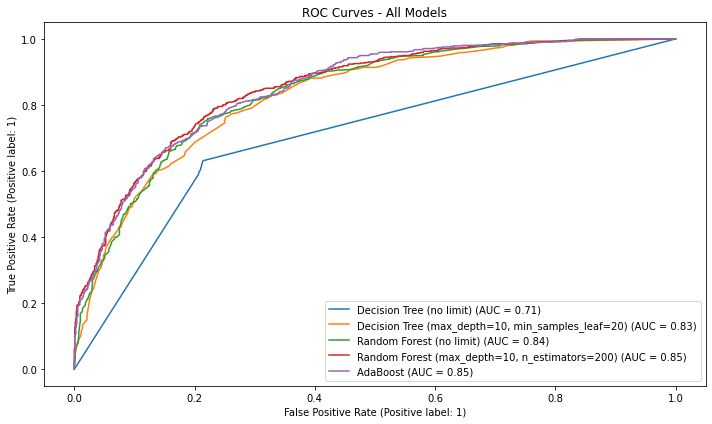

In [24]:
# plot ROC curves for all models

plt.figure(figsize=(10, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=plt.gca(), name=name)

plt.title('ROC Curves - All Models')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

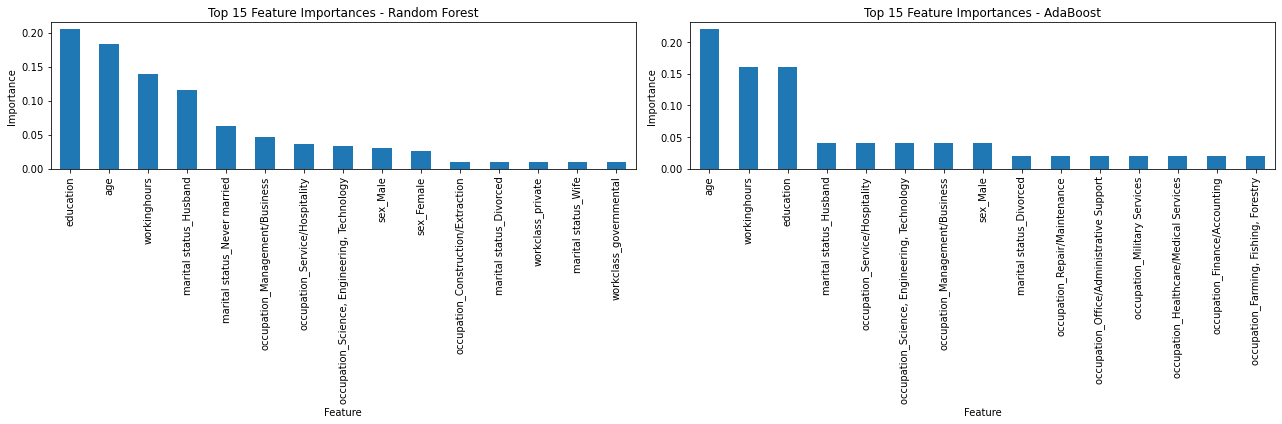

Random Forest top 10:
education                                      0.204823
age                                            0.182797
workinghours                                   0.139449
marital status_Husband                         0.114962
marital status_Never married                   0.063106
occupation_Management/Business                 0.046127
occupation_Service/Hospitality                 0.036186
occupation_Science, Engineering, Technology    0.033171
sex_Male                                       0.030760
sex_Female                                     0.026107
dtype: float64

AdaBoost top 10:
age                                            0.22
workinghours                                   0.16
education                                      0.16
marital status_Husband                         0.04
occupation_Service/Hospitality                 0.04
occupation_Science, Engineering, Technology    0.04
occupation_Management/Business                 0.04
sex_Male             

In [25]:
# feature importance from AdaBoost and Random Forest

feature_importances_ada = pd.Series(ada.feature_importances_, index=x_train.columns)
feature_importances_ada = feature_importances_ada.sort_values(ascending=False)

feature_importances_rf = pd.Series(rf_best.feature_importances_, index=x_train.columns)
feature_importances_rf = feature_importances_rf.sort_values(ascending=False)

# plot comparison

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

feature_importances_rf[:15].plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 15 Feature Importances - Random Forest')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importance')

feature_importances_ada[:15].plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 15 Feature Importances - AdaBoost')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Random Forest top 10:")
print(feature_importances_rf[:10])
print("\nAdaBoost top 10:")
print(feature_importances_ada[:10])

In [26]:
# select top 10 features using SelectKBest

selector = SelectKBest(f_classif, k=10)
selector.fit(x_train, y_train)

selected_features_kbest = x_train.columns[selector.get_support()].tolist()
print("SelectKBest top 10 features:", selected_features_kbest)

# compare with Random Forest top 10

top_features_rf = feature_importances_rf[:10].index.tolist()
print("\nRandom Forest top 10:", top_features_rf)

SelectKBest top 10 features: ['age', 'education', 'workinghours', 'marital status_Husband', 'marital status_Never married', 'occupation_Management/Business', 'occupation_Science, Engineering, Technology', 'occupation_Service/Hospitality', 'sex_Female', 'sex_Male']

Random Forest top 10: ['education', 'age', 'workinghours', 'marital status_Husband', 'marital status_Never married', 'occupation_Management/Business', 'occupation_Service/Hospitality', 'occupation_Science, Engineering, Technology', 'sex_Male', 'sex_Female']


In [27]:
# retrain AdaBoost with RF and SelectKBest features

x_train_selected = x_train[top_features_rf]
x_test_selected = x_test[top_features_rf]
x_train_kbest = x_train[selected_features_kbest]
x_test_kbest = x_test[selected_features_kbest]

ada_selected = AdaBoostClassifier(random_state=42)
ada_selected.fit(x_train_selected, y_train)

ada_kbest = AdaBoostClassifier(random_state=42)
ada_kbest.fit(x_train_kbest, y_train)

# compare performance

print("\nAdaBoost (all features)")
print("Accuracy:", ada.score(x_test, y_test))
print("AUC:", roc_auc_score(y_test, ada.predict_proba(x_test)[:, 1]))

print("\nAdaBoost (RF top 10 features)")
print("Accuracy:", ada_selected.score(x_test_selected, y_test))
print("AUC:", roc_auc_score(y_test, ada_selected.predict_proba(x_test_selected)[:, 1]))

print("\nAdaBoost (SelectKBest top 10 features)")
print("Accuracy:", ada_kbest.score(x_test_kbest, y_test))
print("AUC:", roc_auc_score(y_test, ada_kbest.predict_proba(x_test_kbest)[:, 1]))


AdaBoost (all features)
Accuracy: 0.7877777777777778
AUC: 0.8506945967883468

AdaBoost (RF top 10 features)
Accuracy: 0.7844444444444445
AUC: 0.8474738943488943

AdaBoost (SelectKBest top 10 features)
Accuracy: 0.7844444444444445
AUC: 0.8474738943488943


# **Task 2**

In [28]:
# create SHAP explainer for AdaBoost

explainer = shap.KernelExplainer(ada.predict_proba, shap.kmeans(x_train, 10))

# calculate SHAP values on a sample of 100 instances (KernelExplainer is slow)

x_test_sample = x_test.sample(100, random_state=42)
shap_values = explainer.shap_values(x_test_sample)

print(type(shap_values))
print(len(shap_values))

  0%|          | 0/100 [00:00<?, ?it/s]

<class 'list'>
2


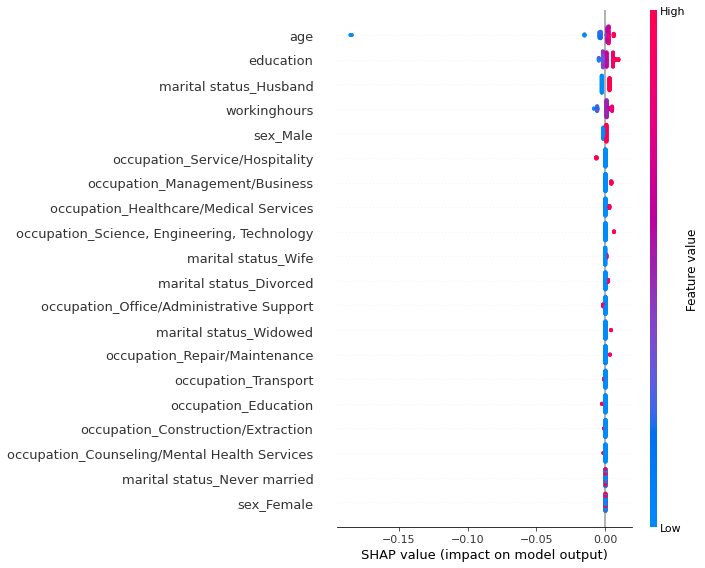

In [29]:
# summary plot

plt.figure(facecolor='white')
shap.summary_plot(shap_values[1], x_test_sample, 
                  feature_names=x_test.columns, 
                  show=False,
                  plot_size=(10, 8))
plt.gcf().set_facecolor('white')
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [30]:
# print SHAP values for person 0 and person 1

for i in [0, 1]:
    print(f"\n Person {i}")
    print(f"Prediction: {'high' if ada.predict(x_test_sample.iloc[[i]])[0] == 1 else 'low'}")
    print(f"Actual: {'high' if y_test.iloc[i] == 1 else 'low'}")
    
    # top 5 features pushing towards high
    
    shap_vals = pd.Series(shap_values[1][i], index=x_test.columns)
    shap_vals = shap_vals.sort_values(ascending=False)
    print("\nTop features pushing towards HIGH:")
    print(shap_vals.head(3))
    print("\nTop features pushing towards LOW:")
    print(shap_vals.tail(3))


 Person 0
Prediction: high
Actual: low

Top features pushing towards HIGH:
workinghours                      0.004820
occupation_Management/Business    0.004244
age                               0.002288
dtype: float64

Top features pushing towards LOW:
marital status_Wife      -0.000192
education                -0.001832
marital status_Husband   -0.002623
dtype: float64

 Person 1
Prediction: low
Actual: low

Top features pushing towards HIGH:
age                                      0.001426
workinghours                             0.000852
occupation_Farming, Fishing, Forestry    0.000000
dtype: float64

Top features pushing towards LOW:
occupation_Office/Administrative Support   -0.001559
education                                  -0.001832
marital status_Husband                     -0.002623
dtype: float64


# **Task 3**

In [31]:
income_test = pd.read_csv('income_test.csv')
income_test.head()

,age,workclass,education,marital status,occupation,workinghours,sex,ability to speak english,gave birth this year
0,61,private,18,Husband,Sales,45,Male,NaN,NaN
1,62,private,21,Husband,Sales,60,Male,NaN,NaN
2,75,governmental,24,Widowed,Education,56,Female,NaN,NaN
3,20,private,16,Never married,"Farming, Fishing, Forestry",45,Male,NaN,NaN
4,41,private,17,Husband,Production/Assembly,80,Male,NaN,NaN


In [32]:
# apply same preprocessing as training data

income_test = income_test.drop(columns=['ability to speak english', 'gave birth this year'])
income_test = pd.get_dummies(income_test, columns=['workclass', 'marital status', 'occupation', 'sex'])
income_test = income_test.reindex(columns=x.columns, fill_value=0)
income_test[numerical_cols] = scaler.transform(income_test[numerical_cols])

In [33]:
# generate predictions

predictions = ada.predict(income_test)
probabilities = ada.predict_proba(income_test)[:, 1]

print("Predictions distribution:")
print(pd.Series(predictions).map({0: 'low', 1: 'high'}).value_counts())
print(f"\nPredicted high income: {predictions.sum()} out of {len(predictions)}")

Predictions distribution:
low     1010
high     990
dtype: int64

Predicted high income: 990 out of 2000


In [34]:
# gender fairness analysis

income_test_raw = pd.read_csv('income_test.csv')
income_test_raw = income_test_raw.drop(columns=['ability to speak english', 'gave birth this year'])

# add predictions to raw data

income_test_raw['predicted_income'] = pd.Series(predictions).map({0: 'low', 1: 'high'})

# fairness by gender

print("Predictions by gender:")
print(income_test_raw.groupby('sex')['predicted_income'].value_counts())
print("\nPercentage predicted high by gender:")
print(income_test_raw.groupby('sex')['predicted_income'].apply(
    lambda x: (x == 'high').mean() * 100).round(1))

Predictions by gender:
sex     predicted_income
Female  low                 600
        high                247
Male    high                743
        low                 410
Name: predicted_income, dtype: int64

Percentage predicted high by gender:
sex
Female    29.2
Male      64.4
Name: predicted_income, dtype: float64


In [35]:
template = pd.read_csv('predictions_template.csv')

In [36]:
# fill predictions template

template['income'] = pd.Series(predictions).map({0: 'low', 1: 'high'})

In [37]:
# save to csv

template.to_csv('predictions_template.csv', index=False)

print(template.head())
print(template['income'].value_counts())

   id income
0   1   high
1   2   high
2   3   high
3   4    low
4   5   high
low     1010
high     990
Name: income, dtype: int64


In [38]:
# check alignment

print("Template shape:", template.shape)
print("Predictions shape:", predictions.shape)
print("\nFirst 5 ids:", template['id'].head().tolist())
print("First 5 predictions:", list(pd.Series(predictions[:5]).map({0: 'low', 1: 'high'})))

Template shape: (2000, 2)
Predictions shape: (2000,)

First 5 ids: [1, 2, 3, 4, 5]
First 5 predictions: ['high', 'high', 'high', 'low', 'high']
